<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>06 $\rightarrow$ License Plate Detection & Privacy Anonymization</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Automated Vehicle Plate Localization & Median Blur Privacy Anonymization)</span>
</div>

---

## Overview
In this notebook, we detect vehicle **License Plates** and implement **Privacy Anonymization** (automatic plate blurring).

### Key Concepts Covered:
1. Loading the license plate cascade classifier (`haarcascade_plate_number.xml`).
2. Localizing license plate bounding coordinates $(x, y, w, h)$.
3. Applying **Median Blur** (`cv2.medianBlur`) to anonymize sensitive text information.
4. Comparing original, detected, and privacy-blurred results.
5. Pixel intensity distribution analysis demonstrating the anonymization effect.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load the License Plate Classifier](#2-load-the-license-plate-classifier)
3. [Load and Prepare the Vehicle Image](#3-load-and-prepare-the-vehicle-image)
4. [Detect License Plate](#4-detect-license-plate)
5. [Privacy Blurring Implementation](#5-privacy-blurring-implementation)
6. [Visualizations](#6-visualizations)
   - 6.1 [Plot 1: 3-Panel Complete Pipeline Comparison](#61-plot-1-3-panel-complete-pipeline-comparison)
   - 6.2 [Plot 2: Close-Up ROI Comparison (Clear vs Blurred Plate)](#62-plot-2-close-up-roi-comparison-clear-vs-blurred-plate)
   - 6.3 [Plot 3: Pixel Intensity Distribution (Clear vs Blurred Plate)](#63-plot-3-pixel-intensity-distribution-clear-vs-blurred-plate)
7. [Key Takeaways](#7-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a id="2-load-the-license-plate-classifier"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load the License Plate Classifier</span>

In [2]:
plate_cascade_path = 'Haarcascades/haarcascade_plate_number.xml'
plate_classifier = cv2.CascadeClassifier(plate_cascade_path)

if plate_classifier.empty():
    print("Error: Could not load plate classifier from:", plate_cascade_path)
else:
    print("License plate classifier loaded successfully!")

License plate classifier loaded successfully!


<a id="3-load-and-prepare-the-vehicle-image"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Load and Prepare the Vehicle Image</span>

In [3]:
image_bgr = cv2.imread('assets/images/car_plate.jpg')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Vehicle Image Dimensions: {image_rgb.shape[1]} x {image_rgb.shape[0]} px")

Vehicle Image Dimensions: 1024 x 1024 px


<a id="4-detect-license-plate"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Detect License Plate</span>

In [4]:
plates = plate_classifier.detectMultiScale(image_gray, scaleFactor=1.1, minNeighbors=3)

print(f"Total license plates detected: {len(plates)}")

if len(plates) == 0:
    print("No plates detected.")
else:
    for i, (x, y, w, h) in enumerate(plates, start=1):
        print(f"Plate {i}: Position=({x}, {y}), Size={w}x{h} px")

Total license plates detected: 1
Plate 1: Position=(379, 534), Size=329x110 px


<a id="5-privacy-blurring-implementation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Privacy Blurring Implementation</span>

We extract the plate ROI, apply `cv2.medianBlur`, and blend it back into the vehicle image.

In [5]:
def detect_and_draw_plate(image_rgb, plate_coords):
    canvas = image_rgb.copy()
    for (x, y, w, h) in plate_coords:
        cv2.rectangle(canvas, (x, y), (x + w, y + h), (255, 0, 0), 4)
        cv2.putText(canvas, "License Plate", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return canvas

def anonymize_plate(image_rgb, plate_coords, kernel_size=35):
    canvas = image_rgb.copy()
    for (x, y, w, h) in plate_coords:
        plate_roi = canvas[y:y+h, x:x+w]
        blurred_roi = cv2.medianBlur(plate_roi, kernel_size)
        canvas[y:y+h, x:x+w] = blurred_roi
    return canvas

plate_boxed_image = detect_and_draw_plate(image_rgb, plates)
plate_blurred_image = anonymize_plate(image_rgb, plates, kernel_size=35)

<a id="6-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Visualizations</span>

<a id="61-plot-1-3-panel-complete-pipeline-comparison"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Plot 1: 3-Panel Complete Pipeline Comparison</span>

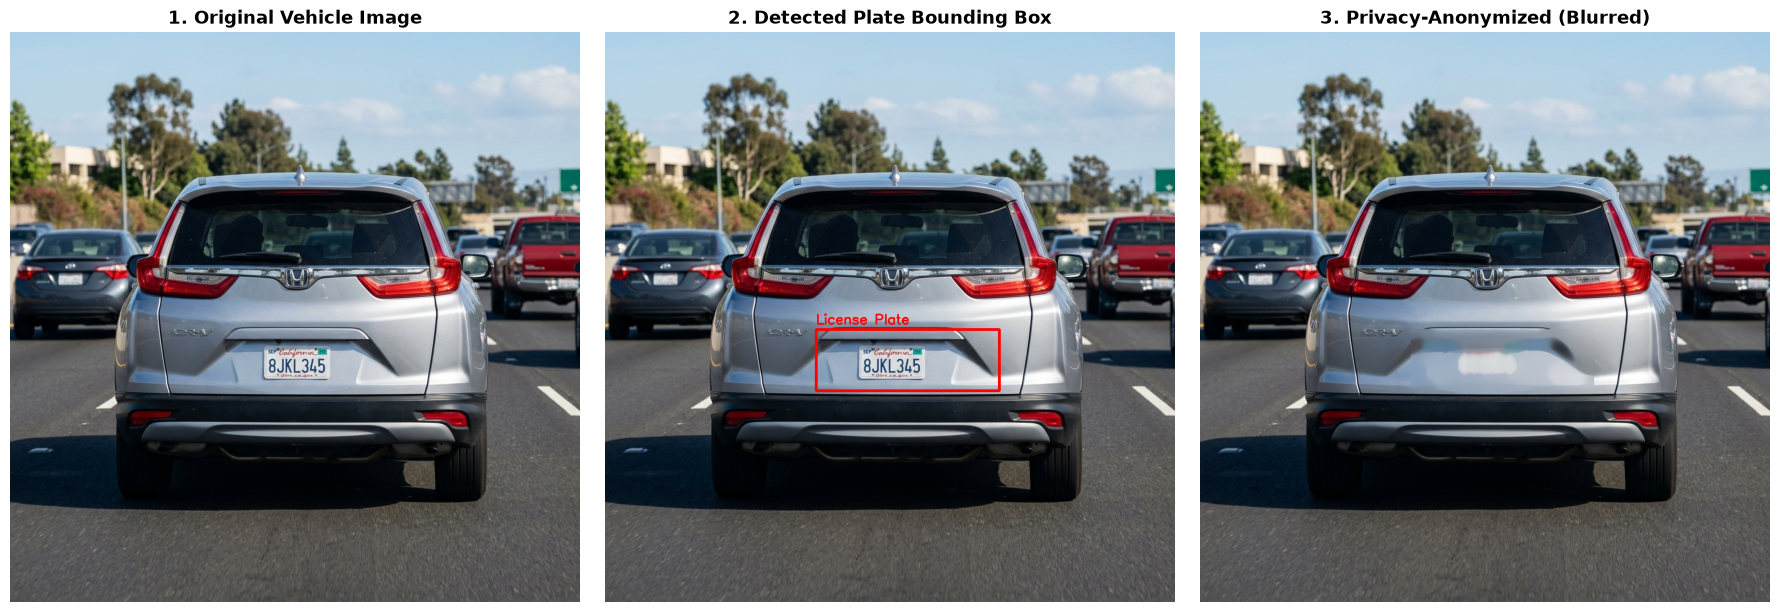

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("1. Original Vehicle Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(plate_boxed_image)
axes[1].set_title("2. Detected Plate Bounding Box", fontsize=13, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(plate_blurred_image)
axes[2].set_title("3. Privacy-Anonymized (Blurred)", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

<a id="62-plot-2-close-up-roi-comparison-clear-vs-blurred-plate"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Plot 2: Close-Up ROI Comparison (Clear vs Blurred Plate)</span>

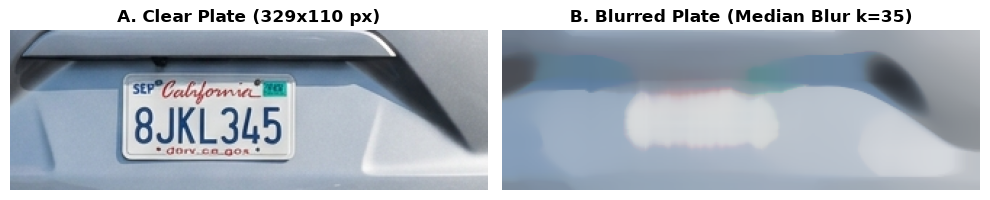

In [7]:
if len(plates) > 0:
    x, y, w, h = plates[0]
    clear_roi = image_rgb[y:y+h, x:x+w]
    blurred_roi = plate_blurred_image[y:y+h, x:x+w]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(clear_roi)
    axes[0].set_title(f"A. Clear Plate ({w}x{h} px)", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(blurred_roi)
    axes[1].set_title("B. Blurred Plate (Median Blur k=35)", fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

<a id="63-plot-3-pixel-intensity-distribution-clear-vs-blurred-plate"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Plot 3: Pixel Intensity Distribution (Clear vs Blurred Plate)</span>

Demonstrating how blurring smooths out high-contrast alphanumeric edges.

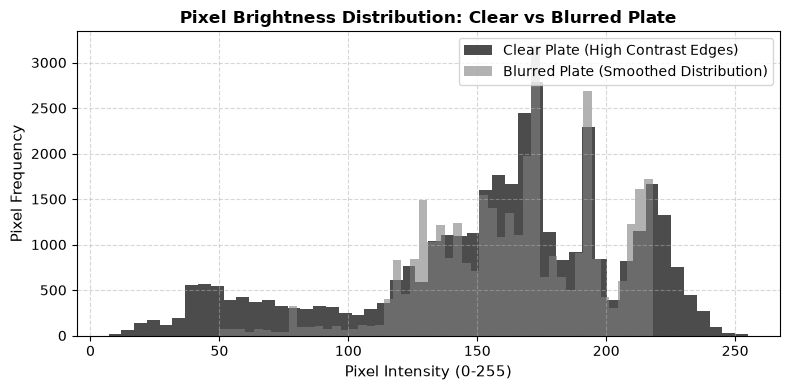

In [8]:
if len(plates) > 0:
    clear_gray = cv2.cvtColor(clear_roi, cv2.COLOR_RGB2GRAY)
    blurred_gray = cv2.cvtColor(blurred_roi, cv2.COLOR_RGB2GRAY)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(clear_gray.ravel(), bins=50, color='black', alpha=0.7, label='Clear Plate (High Contrast Edges)')
    ax.hist(blurred_gray.ravel(), bins=50, color='gray', alpha=0.6, label='Blurred Plate (Smoothed Distribution)')
    
    ax.set_title("Pixel Brightness Distribution: Clear vs Blurred Plate", fontsize=12, fontweight='bold')
    ax.set_xlabel("Pixel Intensity (0-255)", fontsize=11)
    ax.set_ylabel("Pixel Frequency", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

<a id="7-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Key Takeaways</span>

- **Privacy Compliance**: Automatic blurring of sensitive information (license plates, faces) is a legal and ethical requirement in real-world computer vision.
- **Median Blur Strengths**: `cv2.medianBlur` is exceptionally suited for anonymization because it replaces pixel values with local neighborhood medians without halos.
- **Project Completion**: You have now mastered Haar cascades across static faces, eyes, hierarchical search, pedestrian tracking, vehicle monitoring, and privacy protection!